# Video Retrieval on MSVD — Kaggle Notebook

**Architecture:** CLIP ViT-L/14 + STS + FT-Tokens + Sparse MoE + SE-Aggregation + KAN Late-Fusion

**Dataset:** MSVD (Microsoft Video Description)
- 1,970 YouTube clips (.avi)
- Train: ~1,200 | Val: ~100 | Test: ~670 videos
- ~40 captions/video (lọc English)

**JSON structure:**
```json
[{ "video_id": "WTf5EgVY5uU_98_104", "video": "WTf5EgVY5uU_98_104.avi",
   "caption": ["a man ...", "someone is ..."], "source": "MSVD" }, ...]
```

**Pipeline:**
- Phase 1: Extract CLIP features (~10 min, chỉ chạy 1 lần)
- Phase 2: Train head (1-3 min/epoch)
- Phase 3 (optional): Fine-tune CLIP last 2 layers (+5-8% R@1)

**Bugs fixed vs original:**
1. `frames_to_tensor` — clamp resize dims ≥ 224 (tránh negative crop index → shape `1×224`)
2. `CLIP_MEAN/STD` — move to device trước normalize
3. `text_embed_dim=768` tách riêng khỏi `embed_dim=1024`
4. `load_clip_proj_weights` — bỏ copy text_proj (shape mismatch 768×768 vs 768×1024)
5. `KANLayer` — fp16 underflow: ép fp32 bên trong b_splines; mở rộng grid `[-3,3]`; giảm init scale
6. `RetrievalHead.forward` — normalize trước KAN
7. `Trainer.evaluate` — normalize trước KAN (consistent với forward)
8. `logit_scale` — clamp sau mỗi optimizer step

In [62]:
# CELL 1 — Install / Verify
import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    import einops
except ImportError:
    pip('einops')

import torch, torchvision, transformers, cv2
print(f'torch        : {torch.__version__}')
print(f'transformers : {transformers.__version__}')
print(f'CUDA         : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU          : {p.name}  ({p.total_memory/1e9:.1f} GB)')

torch        : 2.10.0+cu128
transformers : 5.0.0
CUDA         : True
GPU          : Tesla T4  (15.6 GB)


In [63]:
# CELL 2 — Imports & Reproducibility
import os, json, random, logging, time
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Dict
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
import cv2
from tqdm.notebook import tqdm
from transformers import CLIPModel, CLIPProcessor, get_cosine_schedule_with_warmup
import torch.backends.cudnn as cudnn

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger(__name__)
cudnn.benchmark = True

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print('Imports OK')

Imports OK


In [64]:
# CELL 3 — Configuration
@dataclass
class Config:
    # ── Paths ──────────────────────────────────────────────────────────
    train_json : str = '/kaggle/input/datasets/chinmaybhangale/msvd-dataset/MSVD/msvd_train.json'
    val_json   : str = '/kaggle/input/datasets/chinmaybhangale/msvd-dataset/MSVD/msvd_val.json'
    test_json  : str = '/kaggle/input/datasets/chinmaybhangale/msvd-dataset/MSVD/msvd_test.json'
    video_dir  : str = '/kaggle/input/datasets/chinmaybhangale/msvd-dataset/MSVD/YouTubeClips'
    feat_dir   : str = '/kaggle/working/features'
    ckpt_dir   : str = '/kaggle/working/checkpoints'

    # ── CLIP backbone ──────────────────────────────────────────────────
    clip_model     : str   = 'openai/clip-vit-large-patch14'
    embed_dim      : int   = 1024   # ViT-L/14 vision  pooler_output dim
    text_embed_dim : int   = 768    # ViT-L/14 text    pooler_output dim  [FIX-3]
    proj_dim       : int   = 768    # joint embedding dim

    # ── Video sampling ─────────────────────────────────────────────────
    num_frames  : int = 8
    frame_size  : int = 224

    # ── Head architecture ──────────────────────────────────────────────
    sts_shift_ratio : float = 0.125
    num_experts     : int   = 4
    top_k_experts   : int   = 2
    moe_hidden_dim  : int   = 1024
    kan_grid        : int   = 5
    kan_spline_order: int   = 3
    kan_hidden      : int   = 256

    # ── Training ───────────────────────────────────────────────────────
    batch_size      : int   = 256
    accum_steps     : int   = 1
    num_epochs      : int   = 50
    lr_proj         : float = 1e-4
    lr_head         : float = 3e-4
    weight_decay    : float = 0.02
    warmup_ratio    : float = 0.05
    grad_clip       : float = 1.0
    temperature_init: float = 0.07
    hard_neg_margin : float = 0.2
    label_smoothing : float = 0.1
    patience        : int   = 10
    min_delta       : float = 0.3
    eval_every      : int   = 1
    # AMP tắt cho training head: KAN b_splines không ổn định với fp16  [FIX-5]
    use_amp         : bool  = False
    log_every       : int   = 20

    # ── Feature extraction ─────────────────────────────────────────────
    extract_batch_size: int = 128
    num_workers       : int = 2

cfg = Config()
cfg.device = 'cuda' if torch.cuda.is_available() else 'cpu'

Path(cfg.feat_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.ckpt_dir).mkdir(parents=True, exist_ok=True)
print(f'Device         : {cfg.device}')
print(f'CLIP model     : {cfg.clip_model}')
print(f'embed_dim      : {cfg.embed_dim}  (vision)')
print(f'text_embed_dim : {cfg.text_embed_dim}  (text)')
print(f'proj_dim       : {cfg.proj_dim}')
print(f'use_amp        : {cfg.use_amp}')

Device         : cuda
CLIP model     : openai/clip-vit-large-patch14
embed_dim      : 1024  (vision)
text_embed_dim : 768  (text)
proj_dim       : 768
use_amp        : False


In [65]:
# CELL 4 — MSVD JSON Parser & Video Decoder

# [FIX-2] CLIP_MEAN/STD stored as 1-D; moved to device inside frames_to_tensor
CLIP_MEAN = torch.tensor([0.48145466, 0.4578275,  0.40821073])
CLIP_STD  = torch.tensor([0.26862954, 0.26130258, 0.27577711])


def load_msvd_split(json_path: str, video_dir: str) -> List[Dict]:
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    samples = []
    for entry in data:
        vid_id   = entry['video_id']
        vid_file = entry['video']
        captions = entry['caption']
        vid_path = os.path.join(video_dir, vid_file)
        for cap in captions:
            cap = cap.strip()
            if cap:
                samples.append({'video_id': vid_id, 'caption': cap,
                                'video_path': vid_path})
    logger.info(f'  {os.path.basename(json_path)}: '
                f'{len(data)} videos | {len(samples)} (video,cap) pairs')
    return samples


def sample_frames_from_video(path: str, num_frames: int) -> Optional[np.ndarray]:
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        return None
    total   = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 1)
    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = frames[-1] if frames else np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return np.stack(frames)


def frames_to_tensor(frames_np: np.ndarray, device: str) -> torch.Tensor:
    """numpy (T,H,W,3) uint8  →  normalized float32 (T,3,224,224) on device."""
    tensors = []
    for f in frames_np:
        h, w = f.shape[:2]
        scale = 224 / min(h, w)
        # [FIX-1] clamp to ≥ 224: int() truncation can give nh/nw = 223,
        # making y0/x0 = -1, and numpy slice f[-1:223] returns only 1 row.
        nh = max(int(h * scale), 224)
        nw = max(int(w * scale), 224)
        f  = cv2.resize(f, (nw, nh), interpolation=cv2.INTER_LINEAR)
        y0 = (nh - 224) // 2
        x0 = (nw - 224) // 2
        f  = f[y0:y0+224, x0:x0+224]
        tensors.append(torch.from_numpy(f).permute(2, 0, 1).float() / 255.0)

    pv   = torch.stack(tensors)                      # (T,3,224,224)
    mean = CLIP_MEAN.view(1, 3, 1, 1).to(device)    # [FIX-2] move to device here
    std  = CLIP_STD.view(1, 3, 1, 1).to(device)
    return (pv.to(device) - mean) / std


print('Loading splits...')
train_s = load_msvd_split(cfg.train_json, cfg.video_dir)
val_s   = load_msvd_split(cfg.val_json,   cfg.video_dir)
test_s  = load_msvd_split(cfg.test_json,  cfg.video_dir)

for name, samples in [('train', train_s), ('val', val_s), ('test', test_s)]:
    n_vid = len({s['video_id'] for s in samples})
    n_cap = len(samples)
    print(f'  {name:<6}: {n_vid:5d} videos | {n_cap:6d} captions '
          f'(avg {n_cap/n_vid:.1f} caps/video)')

print('\nSample captions:')
for s in train_s[:4]:
    print(f'  [{s["video_id"]}] {s["caption"]}')

2026-05-16 03:22:46,980 | INFO |   msvd_train.json: 1200 videos | 48774 (video,cap) pairs
2026-05-16 03:22:46,997 | INFO |   msvd_val.json: 100 videos | 4290 (video,cap) pairs
2026-05-16 03:22:47,017 | INFO |   msvd_test.json: 670 videos | 27763 (video,cap) pairs


Loading splits...
  train :  1200 videos |  48774 captions (avg 40.6 caps/video)
  val   :   100 videos |   4290 captions (avg 42.9 caps/video)
  test  :   670 videos |  27763 captions (avg 41.4 caps/video)

Sample captions:
  [WTf5EgVY5uU_98_104] a woman breaks an egg
  [WTf5EgVY5uU_98_104] a woman breaks two eggs in a bowl
  [WTf5EgVY5uU_98_104] a woman cracks an egg against the rim of a glass bowl and puts it inside
  [WTf5EgVY5uU_98_104] a woman cracks an egg and puts it into a bowl with another egg


JSON files:
  OK      msvd_train.json                          2.3 MB
  OK      msvd_val.json                            0.2 MB
  OK      msvd_test.json                           1.3 MB
Video dir:
  OK      YouTubeClips/                            1970 files


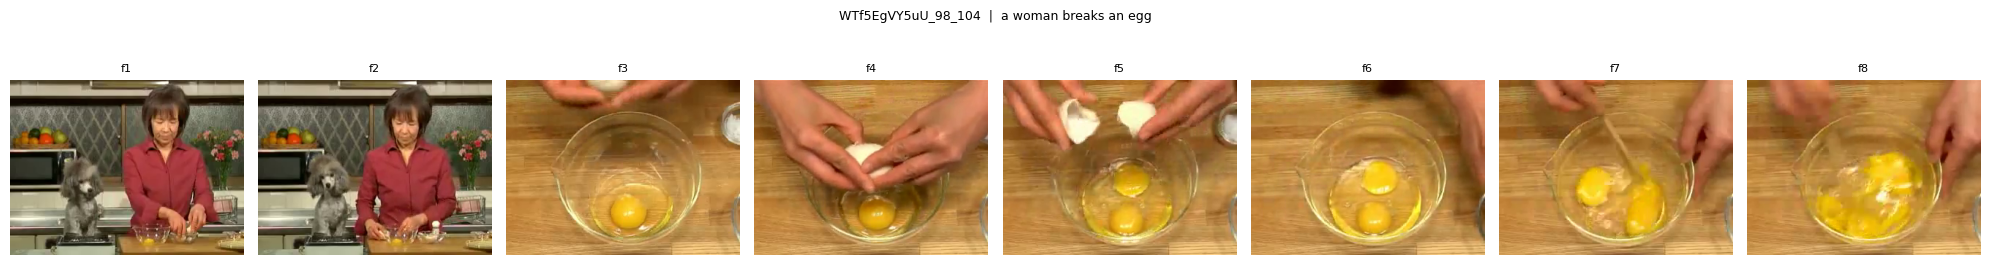

In [66]:
# CELL 5 — Verify Paths & Preview Frames
import glob, matplotlib.pyplot as plt

def check(label, path):
    exists = os.path.exists(path)
    if os.path.isdir(path):
        n = len(glob.glob(os.path.join(path, '*')))
        detail = f'{n} files'
    elif os.path.isfile(path):
        detail = f'{os.path.getsize(path)/1e6:.1f} MB'
    else:
        detail = 'NOT FOUND'
    print(f'  {"OK" if exists else "MISSING":7} {label:<40} {detail}')

print('JSON files:')
check('msvd_train.json', cfg.train_json)
check('msvd_val.json',   cfg.val_json)
check('msvd_test.json',  cfg.test_json)
print('Video dir:')
check('YouTubeClips/',   cfg.video_dir)

sample = train_s[0]
if os.path.exists(sample['video_path']):
    frames = sample_frames_from_video(sample['video_path'], 8)
    if frames is not None:
        fig, axes = plt.subplots(1, 8, figsize=(20, 3))
        for i, ax in enumerate(axes):
            ax.imshow(frames[i]); ax.set_title(f'f{i+1}', fontsize=8); ax.axis('off')
        plt.suptitle(f"{sample['video_id']}  |  {sample['caption'][:60]}", fontsize=9)
        plt.tight_layout(); plt.show()
else:
    print(f'Video not found: {sample["video_path"]}')

## Phase 1 — Offline Feature Extraction (chạy 1 lần, ~10 min)

In [67]:
# CELL 6 — Extract & Save CLIP Features
#
# Output layout:
#   features/train_features.pt  →  list of dicts:
#     { video_id, caption,
#       video_feats: Tensor(T, 1024) float16,
#       text_feat:   Tensor(768,)    float16 }   ← text dim = 768, NOT 1024
#
# Note: clip.text_model().pooler_output is 768-dim for ViT-L/14.
# We save it as-is; text_proj is built with text_embed_dim=768.  [FIX-3]

def extract_msvd_features(
    json_path:       str,
    video_dir:       str,
    out_path:        str,
    clip_model_name: str,
    num_frames:      int,
    device:          str,
    text_batch_size: int = 128,
):
    if os.path.exists(out_path):
        print(f'Exists: {out_path} — skip')
        # Quick dim check
        recs = torch.load(out_path, weights_only=False)
        print(f'  video_feats: {recs[0]["video_feats"].shape} '
              f'{recs[0]["video_feats"].dtype}')
        print(f'  text_feat  : {recs[0]["text_feat"].shape} '
              f'{recs[0]["text_feat"].dtype}')
        del recs
        return

    print(f'\nExtracting -> {out_path}')
    clip = CLIPModel.from_pretrained(clip_model_name).to(device)
    proc = CLIPProcessor.from_pretrained(clip_model_name)
    clip.eval()

    samples = load_msvd_split(json_path, video_dir)

    # 1. Video features
    print('  [1/2] Video features...')
    unique_vids = {}
    for s in samples:
        if s['video_id'] not in unique_vids:
            unique_vids[s['video_id']] = s['video_path']

    vid_cache = {}
    for vid_id, vid_path in tqdm(unique_vids.items(), desc='Video'):
        frames_np = sample_frames_from_video(vid_path, num_frames)
        if frames_np is None:
            frames_np = np.zeros((num_frames, 224, 224, 3), dtype=np.uint8)
        pv = frames_to_tensor(frames_np, device)   # (T,3,224,224)
        with torch.no_grad():
            # Feature extraction always in fp32 for stability
            out  = clip.vision_model(pixel_values=pv.float())
            feat = out.pooler_output                           # (T, 1024)
        vid_cache[vid_id] = feat.cpu().half()

    # 2. Text features — pooler_output is 768-dim for ViT-L/14
    print('  [2/2] Text features (batched)...')
    all_caps   = [s['caption'] for s in samples]
    all_t_feat = []
    for i in tqdm(range(0, len(all_caps), text_batch_size), desc='Text'):
        batch = all_caps[i:i+text_batch_size]
        enc   = proc(text=batch, return_tensors='pt',
                     padding=True, truncation=True, max_length=77)
        enc   = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out  = clip.text_model(input_ids=enc['input_ids'],
                                   attention_mask=enc['attention_mask'])
            feat = out.pooler_output                           # (bs, 768)
        all_t_feat.append(feat.cpu().half())
    text_feats = torch.cat(all_t_feat)   # (N, 768)

    # 3. Assemble & save
    records = [
        {
            'video_id':    s['video_id'],
            'caption':     s['caption'],
            'video_feats': vid_cache[s['video_id']],  # (T, 1024) fp16
            'text_feat':   text_feats[i],             # (768,)    fp16
        }
        for i, s in enumerate(samples)
    ]
    torch.save(records, out_path)

    n_vid = len(unique_vids)
    print(f'  Saved {len(records):,} records ({n_vid} videos) -> {out_path}')
    print(f'  video_feats: {records[0]["video_feats"].shape}  '
          f'{records[0]["video_feats"].dtype}')
    print(f'  text_feat  : {records[0]["text_feat"].shape}  '
          f'{records[0]["text_feat"].dtype}')
    del clip; torch.cuda.empty_cache()


_dev  = cfg.device
_clip = cfg.clip_model

extract_msvd_features(cfg.train_json, cfg.video_dir,
    f'{cfg.feat_dir}/train_features.pt', _clip, cfg.num_frames, _dev)

extract_msvd_features(cfg.val_json, cfg.video_dir,
    f'{cfg.feat_dir}/val_features.pt',   _clip, cfg.num_frames, _dev)

extract_msvd_features(cfg.test_json, cfg.video_dir,
    f'{cfg.feat_dir}/test_features.pt',  _clip, cfg.num_frames, _dev)

print('\nFeature summary:')
for split in ['train', 'val', 'test']:
    p = f'{cfg.feat_dir}/{split}_features.pt'
    if os.path.exists(p):
        recs  = torch.load(p, weights_only=False)
        mb    = os.path.getsize(p) / 1e6
        n_vid = len({r['video_id'] for r in recs})
        print(f'  {split:6}: {n_vid:5d} videos | {len(recs):6d} pairs | {mb:.0f} MB')
        del recs

Exists: /kaggle/working/features/train_features.pt — skip
  video_feats: torch.Size([8, 1024]) torch.float16
  text_feat  : torch.Size([768]) torch.float16
Exists: /kaggle/working/features/val_features.pt — skip
  video_feats: torch.Size([8, 1024]) torch.float16
  text_feat  : torch.Size([768]) torch.float16
Exists: /kaggle/working/features/test_features.pt — skip
  video_feats: torch.Size([8, 1024]) torch.float16
  text_feat  : torch.Size([768]) torch.float16

Feature summary:
  train :  1200 videos |  48774 pairs | 102 MB
  val   :   100 videos |   4290 pairs | 9 MB
  test  :   670 videos |  27763 pairs | 58 MB


## Phase 2 — Train Head on Extracted Features

In [68]:
# CELL 7 — Model Architecture
# STS | FT-Tokens | Sparse MoE | SE-Aggregation | KAN Late-Fusion

class SpatialTemporalShift(nn.Module):
    def __init__(self, r=0.125):
        super().__init__(); self.r = r
    def forward(self, x):   # (B,T,D)
        B, T, D = x.shape; n = max(1, int(D * self.r))
        out = x.clone()
        out[:, 1:,    :n]    = x[:, :-1,   :n];   out[:, 0,    :n]    = x[:, 0,    :n]
        out[:, :-1, n:2*n]   = x[:, 1:,  n:2*n];  out[:, -1, n:2*n]   = x[:, -1, n:2*n]
        return out


class FrameTemporalTokens(nn.Module):
    def __init__(self, num_tokens=4, d=1024):
        super().__init__()
        self.tokens = nn.Parameter(torch.randn(1, num_tokens, d) * 0.02)
        self.attn   = nn.MultiheadAttention(d, num_heads=8, batch_first=True, dropout=0.1)
        self.norm   = nn.LayerNorm(d)
    def forward(self, x):
        B = x.size(0)
        ctx, _ = self.attn(self.tokens.expand(B, -1, -1), x, x)
        return self.norm(x + ctx.mean(1, keepdim=True))


class ExpertFFN(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, h), nn.GELU(),
                                 nn.Dropout(0.1), nn.Linear(h, d))
    def forward(self, x): return self.net(x)


class SparseMoE(nn.Module):
    def __init__(self, d, h, n=4, k=2):
        super().__init__()
        self.n = n; self.k = k
        self.experts = nn.ModuleList([ExpertFFN(d, h) for _ in range(n)])
        self.gate    = nn.Linear(d, n, bias=False)
        self.norm    = nn.LayerNorm(d)
    def forward(self, x):
        B, T, D = x.shape; xf = x.view(B * T, D)
        lg = self.gate(xf)
        if self.training: lg = lg + torch.randn_like(lg) * 0.01
        vals, idx = torch.topk(lg, self.k, dim=-1)
        w = F.softmax(vals, dim=-1); out = torch.zeros_like(xf)
        for ki in range(self.k):
            ei = idx[:, ki]; wk = w[:, ki]
            for e in range(self.n):
                m = (ei == e)
                if m.any():
                    out[m] += wk[m].unsqueeze(-1) * self.experts[e](xf[m])
        return self.norm(out.view(B, T, D) + x)


class ExcitationAggregation(nn.Module):
    def __init__(self, d, r=4):
        super().__init__()
        self.se = nn.Sequential(nn.Linear(d, d // r), nn.ReLU(),
                                nn.Linear(d // r, 1))
    def forward(self, x):   # (B,T,D) -> (B,D)
        w = torch.sigmoid(self.se(x))
        return (x * w).sum(1) / (w.sum(1) + 1e-6)


class KANLayer(nn.Module):
    """
    [FIX-5] Three changes vs original:
      a) grid_range expanded to (-3, 3) — projection outputs are ~N(0,1)
         after normalize; original (-1,1) caused all spline bases = 0
         outside grid → LayerNorm(zeros) = NaN.
      b) init scale 0.1 → 0.02 to reduce early gradient explosion.
      c) b_splines() casts to float32 internally — fp16 underflows 1e-8
         denominator to 0, producing inf/NaN through the division.
    """
    def __init__(self, in_d, out_d, gs=5, so=3, grid_range=(-3.0, 3.0)):
        super().__init__()
        self.so      = so
        self.base_w   = nn.Parameter(torch.randn(out_d, in_d) * 0.02)
        self.spline_w = nn.Parameter(torch.randn(out_d, in_d, gs + so) * 0.02)
        lo, hi = grid_range
        h = (hi - lo) / gs
        self.register_buffer('grid', torch.arange(-so, gs + so + 1) * h + lo)
        self.silu = nn.SiLU()

    def b_splines(self, x: torch.Tensor) -> torch.Tensor:
        # [FIX-5c] force fp32 so 1e-8 doesn't underflow under autocast
        x = x.float().unsqueeze(-1)
        g = self.grid.float()[None, None, :]
        b = ((x >= g[:, :, :-1]) & (x < g[:, :, 1:])).float()
        for k in range(1, self.so + 1):
            l = (x - g[:, :, :-(k+1)]) / (g[:, :, k:-1] - g[:, :, :-(k+1)] + 1e-8)
            r = (g[:, :, k+1:] - x)    / (g[:, :, k+1:] - g[:, :, 1:-k]   + 1e-8)
            b = l * b[:, :, :-1] + r * b[:, :, 1:]
        return b

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x32 = x.float()
        base   = F.linear(self.silu(x32), self.base_w.float())
        spline = torch.einsum('big,oig->bo',
                              self.b_splines(x32),
                              self.spline_w.float())
        return (base + spline).to(x.dtype)


class KANFusion(nn.Module):
    def __init__(self, d, p, h=256, gs=5, so=3):
        super().__init__()
        self.video_kan = nn.Sequential(KANLayer(d, h, gs, so),
                                       nn.LayerNorm(h),
                                       KANLayer(h, p, gs, so))
        self.text_kan  = nn.Sequential(KANLayer(d, h, gs, so),
                                       nn.LayerNorm(h),
                                       KANLayer(h, p, gs, so))
    def forward(self, v, t):
        # v, t already L2-normalized before entering KAN
        return (F.normalize(self.video_kan(v), dim=-1),
                F.normalize(self.text_kan(t),  dim=-1))


class RetrievalHead(nn.Module):
    """
    Input:  vid_feat (B, T, embed_dim=1024) | txt_feat (B, text_embed_dim=768)
    Output: v_emb, t_emb (B, proj_dim=768) — L2-normalized
    """
    def __init__(self, cfg):
        super().__init__()
        d  = cfg.embed_dim        # 1024  (vision)
        dt = cfg.text_embed_dim   # 768   (text)   [FIX-3]
        p  = cfg.proj_dim         # 768

        self.sts        = SpatialTemporalShift(cfg.sts_shift_ratio)
        self.ft_tokens  = FrameTemporalTokens(4, d)
        self.moe        = SparseMoE(d, cfg.moe_hidden_dim,
                                    cfg.num_experts, cfg.top_k_experts)
        self.excitation = ExcitationAggregation(d)
        self.vision_proj = nn.Linear(d,  p, bias=False)
        self.text_proj   = nn.Linear(dt, p, bias=False)   # [FIX-3]
        self.kan_fusion  = KANFusion(p, p, cfg.kan_hidden,
                                     cfg.kan_grid, cfg.kan_spline_order)
        self.logit_scale = nn.Parameter(
            torch.ones([]) * np.log(1 / cfg.temperature_init))
        nn.init.normal_(self.vision_proj.weight, std=0.02)
        nn.init.normal_(self.text_proj.weight,   std=0.02)

    def encode_video(self, vf) -> torch.Tensor:   # (B,T,D) -> (B,P) raw
        x = self.moe(self.ft_tokens(self.sts(vf)))
        return self.vision_proj(self.excitation(x))

    def encode_text(self, tf) -> torch.Tensor:    # (B,dt) -> (B,P) raw
        return self.text_proj(tf)

    def forward(self, vf, tf):
        v = self.encode_video(vf)
        t = self.encode_text(tf)
        # [FIX-6] Normalize to unit sphere BEFORE KAN so inputs stay in grid [-3,3]
        v = F.normalize(v, dim=-1)
        t = F.normalize(t, dim=-1)
        ve, te = self.kan_fusion(v, t)
        return ve, te, self.logit_scale.exp().clamp(max=100)


def load_clip_proj_weights(head: RetrievalHead, clip_name: str, device: str):
    """
    Init vision_proj from CLIP visual_projection (1024→768).
    text_proj is intentionally left at random init:
      CLIP text_projection is (768,768) but head.text_proj is (768,768) now —
      we could copy it, but dimensions differ when text_embed_dim != proj_dim.
      Safest: copy vision, leave text random.  [FIX-4]
    """
    logger.info('Initializing proj from CLIP...')
    clip = CLIPModel.from_pretrained(clip_name)
    head.vision_proj.weight.data.copy_(clip.visual_projection.weight.data)
    # text_proj: only copy if shapes match
    clip_tp = clip.text_projection.weight.data   # (768, 768)
    if head.text_proj.weight.shape == clip_tp.shape:
        head.text_proj.weight.data.copy_(clip_tp)
        logger.info('  vision_proj + text_proj initialized from CLIP')
    else:
        logger.info(f'  vision_proj initialized; text_proj random '
                    f'(shape mismatch: head={head.text_proj.weight.shape} '
                    f'vs clip={clip_tp.shape})')
    del clip; torch.cuda.empty_cache()


_tmp  = RetrievalHead(cfg)
total = sum(p.numel() for p in _tmp.parameters())
print(f'RetrievalHead: {total:,} params  (~{total/1e6:.1f}M)')
del _tmp
print('Model defined OK')

RetrievalHead: 21,325,314 params  (~21.3M)
Model defined OK


In [69]:
# CELL 8 — Loss Functions & Metrics

def bi_nce_loss(v, t, scale, smoothing=0.1):
    B   = v.size(0)
    sim = v @ t.T * scale
    lb  = torch.arange(B, device=v.device)
    if smoothing > 0:
        with torch.no_grad():
            soft = torch.full_like(sim, smoothing / max(B - 1, 1))
            soft.scatter_(1, lb.unsqueeze(1), 1.0 - smoothing)
        lv2t = -(soft * F.log_softmax(sim,   dim=1)).sum(1).mean()
        lt2v = -(soft * F.log_softmax(sim.T, dim=1)).sum(1).mean()
    else:
        lv2t = F.cross_entropy(sim,   lb)
        lt2v = F.cross_entropy(sim.T, lb)
    return (lv2t + lt2v) / 2


def hard_neg_loss(v, t, margin=0.2):
    B = v.size(0)
    sim  = v @ t.T
    diag = sim.diagonal()
    # mask out diagonal for hard-negative mining
    nd = sim - 2 * torch.eye(B, device=sim.device)
    return (F.relu(margin - diag + nd.max(1).values).mean() +
            F.relu(margin - diag + nd.max(0).values).mean()) / 2


def total_loss(v, t, scale, margin=0.2, alpha=0.5, smoothing=0.1):
    return bi_nce_loss(v, t, scale, smoothing) + alpha * hard_neg_loss(v, t, margin)


def compute_metrics_allcaps(V_all: np.ndarray,
                             T_all: np.ndarray,
                             vid_ids: list) -> dict:
    """SOTA protocol: mean similarity across all captions per video."""
    vid2idxs    = defaultdict(list)
    unique_vids = []
    for idx, vid in enumerate(vid_ids):
        if vid not in vid2idxs:
            unique_vids.append(vid)
        vid2idxs[vid].append(idx)

    N_vid = len(unique_vids)
    V     = np.stack([V_all[vid2idxs[v][0]] for v in unique_vids])   # (N_vid, D)

    ranks = np.zeros(N_vid)
    for i, vid in enumerate(unique_vids):
        T_caps   = T_all[vid2idxs[vid]]            # (Ci, D)
        sim_agg  = (T_caps @ V.T).mean(0)          # (N_vid,)
        ranks[i] = np.where(np.argsort(-sim_agg) == i)[0][0] + 1

    return {
        'R@1':   float((ranks <= 1).mean()  * 100),
        'R@5':   float((ranks <= 5).mean()  * 100),
        'R@10':  float((ranks <= 10).mean() * 100),
        'MedR':  float(np.median(ranks)),
        'MeanR': float(ranks.mean()),
    }


print('Loss / Metrics defined OK')

Loss / Metrics defined OK


In [70]:
# CELL 9 — FeatureDataset & Trainer

class FeatureDataset(Dataset):
    def __init__(self, pt_path: str, is_train: bool = True):
        print(f'Loading {pt_path} ...')
        self.records  = torch.load(pt_path, weights_only=False)
        self.is_train = is_train

        self.vid2idxs: Dict[str, List[int]] = defaultdict(list)
        for idx, r in enumerate(self.records):
            self.vid2idxs[r['video_id']].append(idx)

        if is_train:
            self._items = list(range(len(self.records)))
        else:
            self._items = [idxs[0] for idxs in self.vid2idxs.values()]

        n_vid = len(self.vid2idxs)
        print(f'  {"Train" if is_train else "Eval"}: {len(self._items):,} items '
              f'({n_vid} unique videos)')

    def __len__(self): return len(self._items)

    def __getitem__(self, idx):
        base = self._items[idx]
        r    = self.records[base]
        vid  = r['video_id']
        if self.is_train and len(self.vid2idxs[vid]) > 1:
            rand      = self.vid2idxs[vid][
                torch.randint(len(self.vid2idxs[vid]), (1,)).item()]
            text_feat = self.records[rand]['text_feat'].float()
            caption   = self.records[rand]['caption']
        else:
            text_feat = r['text_feat'].float()
            caption   = r['caption']
        return {
            'video_feats': r['video_feats'].float(),   # (T, 1024)
            'text_feats':  text_feat,                  # (768,)
            'video_id':    vid,
            'caption':     caption,
        }


def feat_collate(batch):
    return {
        'video_feats': torch.stack([b['video_feats'] for b in batch]),
        'text_feats':  torch.stack([b['text_feats']  for b in batch]),
        'video_ids':   [b['video_id'] for b in batch],
        'captions':    [b['caption']  for b in batch],
    }


def make_loader(ds, batch_size, shuffle, num_workers):
    kw = dict(batch_size=batch_size, shuffle=shuffle,
              num_workers=num_workers, collate_fn=feat_collate,
              pin_memory=(num_workers > 0), drop_last=shuffle)
    if num_workers > 0:
        kw['persistent_workers'] = True
        kw['prefetch_factor']    = 2
    return DataLoader(ds, **kw)


class Trainer:
    def __init__(self, cfg):
        self.cfg    = cfg
        self.device = torch.device(cfg.device)

        train_pt = f'{cfg.feat_dir}/train_features.pt'
        val_pt   = f'{cfg.feat_dir}/val_features.pt'
        assert os.path.exists(train_pt), f'Missing: {train_pt} — run CELL 6 first!'
        assert os.path.exists(val_pt),   f'Missing: {val_pt}   — run CELL 6 first!'

        self.train_loader = make_loader(
            FeatureDataset(train_pt, is_train=True),
            cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
        self.val_loader = make_loader(
            FeatureDataset(val_pt, is_train=False),
            cfg.batch_size * 2, shuffle=False, num_workers=cfg.num_workers)

        self.model = RetrievalHead(cfg).to(self.device)
        load_clip_proj_weights(self.model, cfg.clip_model, cfg.device)

        tp = sum(p.numel() for p in self.model.parameters())
        tr = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        logger.info(f'Head params: {tr:,} trainable / {tp:,} total')

        proj_p = (list(self.model.vision_proj.parameters()) +
                  list(self.model.text_proj.parameters()))
        head_p = [p for n, p in self.model.named_parameters()
                  if 'vision_proj' not in n and 'text_proj' not in n
                  and p.requires_grad]
        self.opt = torch.optim.AdamW([
            {'params': proj_p, 'lr': cfg.lr_proj},
            {'params': head_p, 'lr': cfg.lr_head}],
            weight_decay=cfg.weight_decay, fused=True)

        steps_ep    = len(self.train_loader)
        total_steps = steps_ep * cfg.num_epochs
        warmup      = max(1, int(total_steps * cfg.warmup_ratio))
        logger.info(f'Steps/ep={steps_ep} | Total={total_steps} | Warmup={warmup}')
        self.sched   = get_cosine_schedule_with_warmup(self.opt, warmup, total_steps)
        self.scaler  = GradScaler('cuda', enabled=cfg.use_amp)
        self.best_r1 = 0.0
        self.history = []

    # ── Train one epoch ────────────────────────────────────────────────
    def train_epoch(self, epoch: int) -> float:
        self.model.train(); total = 0.0
        pbar = tqdm(self.train_loader,
                    desc=f'Ep {epoch+1} [Train]', leave=False)
        for step, batch in enumerate(pbar):
            vf = batch['video_feats'].to(self.device, non_blocking=True)
            tf = batch['text_feats'].to(self.device,  non_blocking=True)

            with autocast(cfg.device, enabled=cfg.use_amp):
                v, t, scale = self.model(vf, tf)
                loss = total_loss(v, t, scale,
                                  cfg.hard_neg_margin,
                                  smoothing=cfg.label_smoothing)
                loss = loss / cfg.accum_steps

            self.scaler.scale(loss).backward()

            if (step + 1) % cfg.accum_steps == 0:
                self.scaler.unscale_(self.opt)
                nn.utils.clip_grad_norm_(self.model.parameters(), cfg.grad_clip)
                self.scaler.step(self.opt)
                self.scaler.update()
                # [FIX-8] clamp logit_scale AFTER optimizer step
                self.model.logit_scale.data.clamp_(0, np.log(100))
                self.opt.zero_grad()
                self.sched.step()

            total += loss.item() * cfg.accum_steps
            if (step + 1) % cfg.log_every == 0:
                pbar.set_postfix(
                    loss=f'{loss.item()*cfg.accum_steps:.4f}',
                    scale=f'{scale.item():.2f}')

        return total / len(self.train_loader)

    # ── Evaluate ───────────────────────────────────────────────────────
    @torch.no_grad()
    def evaluate(self) -> dict:
        self.model.eval()
        all_v, all_t, all_vids = [], [], []

        for batch in tqdm(self.val_loader, desc='Eval', leave=False):
            vf = batch['video_feats'].to(self.device, non_blocking=True)
            tf = batch['text_feats'].to(self.device,  non_blocking=True)

            with autocast(cfg.device, enabled=cfg.use_amp):
                v = self.model.encode_video(vf)
                t = self.model.encode_text(tf)
                # [FIX-7] normalize BEFORE KAN, consistent with forward()
                v = F.normalize(v, dim=-1)
                t = F.normalize(t, dim=-1)
                ve, te = self.model.kan_fusion(v, t)

            all_v.append(ve.cpu().float())
            all_t.append(te.cpu().float())
            all_vids.extend(batch['video_ids'])

        V = torch.cat(all_v).numpy()
        T = torch.cat(all_t).numpy()
        sim   = T @ V.T
        N     = sim.shape[0]
        ranks = np.array([
            np.where(np.argsort(-sim[i]) == i)[0][0] + 1
            for i in range(N)])
        return {
            'R@1':   float((ranks <= 1).mean()  * 100),
            'R@5':   float((ranks <= 5).mean()  * 100),
            'R@10':  float((ranks <= 10).mean() * 100),
            'MedR':  float(np.median(ranks)),
            'MeanR': float(ranks.mean()),
        }

    # ── Full training loop ─────────────────────────────────────────────
    def train(self):
        logger.info('=' * 60)
        logger.info('  MSVD Video Retrieval — Phase 2 Training')
        logger.info(f'  Batch={cfg.batch_size} | Epochs={cfg.num_epochs} '
                    f'| patience={cfg.patience}')
        logger.info('=' * 60)
        no_improve = 0; stopped_early = False

        for epoch in range(cfg.num_epochs):
            t0 = time.time()
            loss = self.train_epoch(epoch)
            dt   = time.time() - t0
            lr   = self.sched.get_last_lr()
            lr_h = lr[1] if len(lr) > 1 else lr[0]
            log  = (f'Ep {epoch+1:>3}/{cfg.num_epochs}'
                    f' | Loss {loss:.4f} | LR {lr_h:.2e} | {dt:.0f}s')

            if (epoch + 1) % cfg.eval_every == 0:
                m = self.evaluate()
                self.history.append({
                    'epoch': epoch + 1, 'loss': loss, 'lr': lr_h,
                    'no_improve': no_improve, **m})
                log += (f" | R@1 {m['R@1']:.2f}"                        f" | R@5 {m['R@5']:.2f}"                        f" | R@10 {m['R@10']:.2f}"                        f" | MedR {m['MedR']:.1f}")
                if m['R@1'] >= self.best_r1 + cfg.min_delta:
                    self.best_r1 = m['R@1']
                    self._save('best_model.pt')
                    no_improve = 0; log += '  <- BEST'
                else:
                    no_improve += 1
                    log += f'  ({no_improve}/{cfg.patience})'

            logger.info(log)

            if no_improve >= cfg.patience:
                logger.info(f'  EARLY STOPPING at epoch {epoch+1}')
                logger.info(f'  Best val R@1: {self.best_r1:.2f}%')
                stopped_early = True; break

        self._save('final_model.pt')
        self._save_history()
        reason = 'early stopping' if stopped_early else 'max epochs'
        logger.info(f'Done — {reason} | Best R@1: {self.best_r1:.2f}%')

    def _save(self, name: str):
        p = os.path.join(cfg.ckpt_dir, name)
        torch.save({'model_state':     self.model.state_dict(),
                    'optimizer_state': self.opt.state_dict(),
                    'best_r1':         self.best_r1}, p)
        logger.info(f'Saved -> {p}')

    def _save_history(self):
        pd.DataFrame(self.history).to_csv(
            os.path.join(cfg.ckpt_dir, 'history.csv'), index=False)

    def load_checkpoint(self, path: str):
        ck = torch.load(path, map_location=self.device, weights_only=True)
        self.model.load_state_dict(ck['model_state'])
        self.best_r1 = ck.get('best_r1', 0.0)
        logger.info(f'Loaded {path} | best_r1={self.best_r1:.2f}%')


print('Trainer defined OK')

Trainer defined OK


In [71]:
# CELL 10 — Sanity Check (forward pass + loss)
device = torch.device(cfg.device)
head   = RetrievalHead(cfg).to(device)

vf = torch.randn(4, cfg.num_frames,    cfg.embed_dim).to(device)   # (4,8,1024)
tf = torch.randn(4, cfg.text_embed_dim             ).to(device)    # (4,768)

with torch.no_grad():
    v, t, scale = head(vf, tf)

print(f'vid_feat {vf.shape} -> v_emb {v.shape}')
print(f'txt_feat {tf.shape} -> t_emb {t.shape}')
print(f'scale : {scale.item():.4f}')
loss = total_loss(v, t, scale, cfg.hard_neg_margin)
print(f'loss  : {loss.item():.4f}')
assert not torch.isnan(loss), 'NaN detected — check model / data!'
assert v.shape == (4, cfg.proj_dim), f'Wrong v shape: {v.shape}'
assert t.shape == (4, cfg.proj_dim), f'Wrong t shape: {t.shape}'
print('Sanity check PASSED')
del head

vid_feat torch.Size([4, 8, 1024]) -> v_emb torch.Size([4, 768])
txt_feat torch.Size([4, 768]) -> t_emb torch.Size([4, 768])
scale : 14.2857
loss  : 1.4866
Sanity check PASSED


## Start Training

In [72]:
# CELL 11 — Train Phase 2 (head only, CLIP frozen)
# ~1-3 min/epoch on T4

trainer = Trainer(cfg)

# To resume from checkpoint:
# trainer.load_checkpoint('/kaggle/working/checkpoints/best_model.pt')

trainer.train()

Loading /kaggle/working/features/train_features.pt ...
  Train: 48,774 items (1200 unique videos)
Loading /kaggle/working/features/val_features.pt ...
  Eval: 100 items (100 unique videos)


2026-05-16 03:22:54,361 | INFO | Initializing proj from CLIP...
2026-05-16 03:22:54,461 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-large-patch14/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-16 03:22:54,478 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-large-patch14/32bd64288804d66eefd0ccbe215aa642df71cc41/config.json "HTTP/1.1 200 OK"
2026-05-16 03:22:54,521 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-large-patch14/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-16 03:22:54,538 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-large-patch14/32bd64288804d66eefd0ccbe215aa642df71cc41/config.json "HTTP/1.1 200 OK"
2026-05-16 03:22:54,581 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-large-patch14/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-16 03:22:55,977 | INFO |   vision_proj + text_proj initialized from CLIP
2026-05-16 03:22:56,042 | INFO | Head params: 21,325,314 trainable / 21,325,314 total
2026-05-16 03:22:56,043 | INFO | Steps/ep=190 | Total=9500 | Warmup=475
2026-05-16 03:22:56,044 | INFO | ============================================================
2026-05-16 03:22:56,045 | INFO |   MSVD Video Retrieval — Phase 2 Training
2026-05-16 03:22:56,045 | INFO |   Batch=256 | Epochs=50 | patience=10
2026-05-16 03:22:56,046 | INFO | ============================================================


Ep 1 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-16 03:28:20,360 | INFO | Ep  25/50 | Loss 1.7348 | LR 1.62e-04 | 13s | R@1 66.00 | R@5 94.00 | R@10 96.00 | MedR 1.0  (9/10)


Ep 26 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-16 03:28:33,145 | INFO | Ep  26/50 | Loss 1.7217 | LR 1.52e-04 | 13s | R@1 70.00 | R@5 94.00 | R@10 96.00 | MedR 1.0  (10/10)
2026-05-16 03:28:33,148 | INFO |   EARLY STOPPING at epoch 26
2026-05-16 03:28:33,149 | INFO |   Best val R@1: 78.00%
2026-05-16 03:28:33,501 | INFO | Saved -> /kaggle/working/checkpoints/final_model.pt
2026-05-16 03:28:33,519 | INFO | Done — early stopping | Best R@1: 78.00%


In [73]:
# CELL 12 — Evaluate on Test Set (all-caps SOTA protocol)
import os, torch
from tqdm.notebook import tqdm

ckpt_path = os.path.join(cfg.ckpt_dir, 'best_model.pt')
assert os.path.exists(ckpt_path), 'Run CELL 11 first!'

ck   = torch.load(ckpt_path, map_location=cfg.device, weights_only=True)
head = RetrievalHead(cfg).to(torch.device(cfg.device))
head.load_state_dict(ck['model_state'])
head.eval()
print(f"Best val R@1: {ck['best_r1']:.2f}%")

test_pt = f'{cfg.feat_dir}/test_features.pt'
assert os.path.exists(test_pt), f'Missing: {test_pt} — run CELL 6!'

test_ds     = FeatureDataset(test_pt, is_train=True)   # all caption pairs
test_loader = make_loader(test_ds, cfg.batch_size * 2,
                          shuffle=False, num_workers=cfg.num_workers)

all_v, all_t, all_vids = [], [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test'):
        vf = batch['video_feats'].to(cfg.device)
        tf = batch['text_feats'].to(cfg.device)
        with autocast(cfg.device, enabled=cfg.use_amp):
            v = head.encode_video(vf)
            t = head.encode_text(tf)
            v = F.normalize(v, dim=-1)     # [FIX-7] consistent normalize
            t = F.normalize(t, dim=-1)
            ve, te = head.kan_fusion(v, t)
        all_v.append(ve.cpu().float())
        all_t.append(te.cpu().float())
        all_vids.extend(batch['video_ids'])

V = torch.cat(all_v).numpy()
T = torch.cat(all_t).numpy()
m = compute_metrics_allcaps(V, T, all_vids)
n_vid = len({v for v in all_vids})
print(f'\nTest: {n_vid} videos  ({len(all_vids)} caption pairs)')
print('── TEST (Text→Video, all-caps mean) ───────')
for k, val in m.items():
    print(f'  {k:<8}: {val:.2f}')

Best val R@1: 78.00%
Loading /kaggle/working/features/test_features.pt ...
  Train: 27,763 items (670 unique videos)


Test:   0%|          | 0/55 [00:00<?, ?it/s]


Test: 670 videos  (27763 caption pairs)
── TEST (Text→Video, all-caps mean) ───────
  R@1     : 52.24
  R@5     : 84.03
  R@10    : 90.75
  MedR    : 1.00
  MeanR   : 6.33


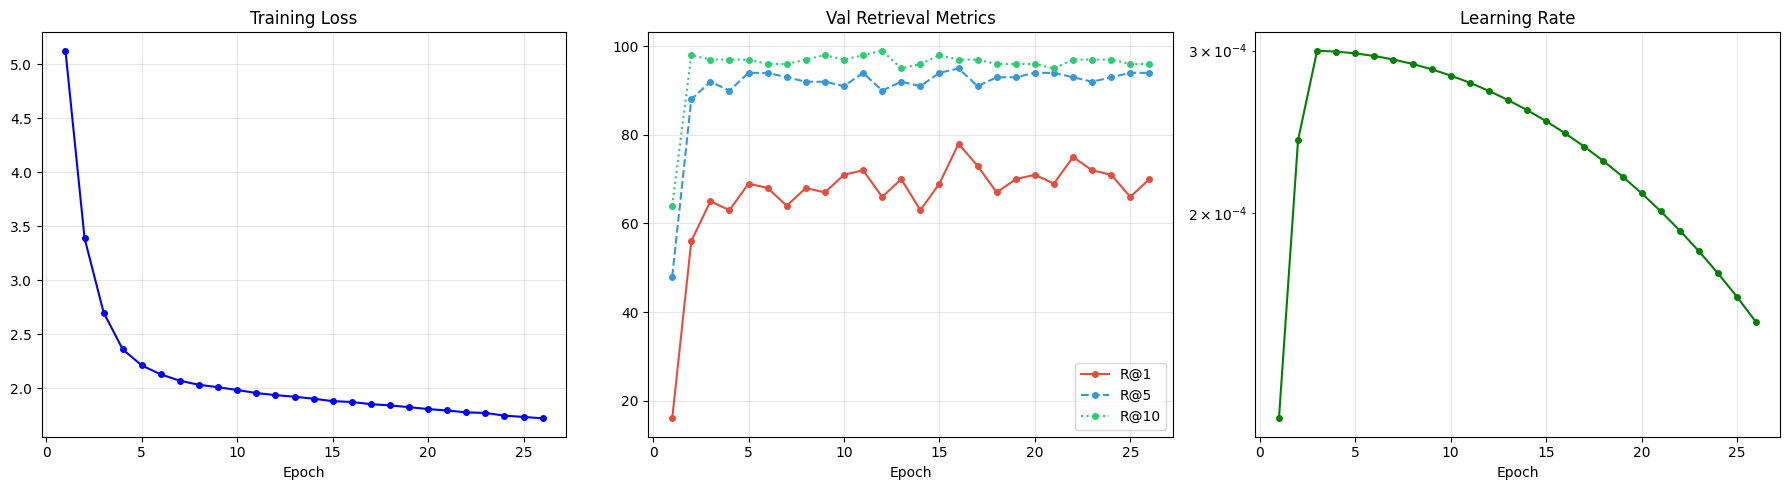

Saved -> /kaggle/working/checkpoints/training_curves.png


In [74]:
# CELL 13 — Training Curves
import matplotlib.pyplot as plt

hist = pd.read_csv(os.path.join(cfg.ckpt_dir, 'history.csv'))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hist['epoch'], hist['loss'], 'b-o', ms=4)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

for col, c, ls in [('R@1', '#e74c3c', '-'),
                   ('R@5', '#3498db', '--'),
                   ('R@10','#2ecc71', ':')]:
    axes[1].plot(hist['epoch'], hist[col], color=c, ls=ls,
                 marker='o', ms=4, label=col)
axes[1].set_title('Val Retrieval Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(hist['epoch'], hist['lr'], 'g-o', ms=4)
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

plt.tight_layout()
out = os.path.join(cfg.ckpt_dir, 'training_curves.png')
plt.savefig(out, dpi=150); plt.show()
print(f'Saved -> {out}')